# Land Cover × Bus Isochrones — Londrina  `v03`
# gee_env
Overlay da classificação de uso do solo (DINOv2+LoRA, 2024) com a infraestrutura de ônibus (CMTU).  
Isócronas de 60 minutos por ônibus a partir de 4 pontos (Norte, Leste, Sul, Oeste).  
Parâmetros: velocidade 20 km/h, espera 10 min, caminhada inicial/final 5 min cada, transbordo 5 min.  

**v03** — caminhadas inicial e final modeladas pela **rede pedestre OSM** (em vez de raio euclidiano).  
Viagem de ônibus: distância pela trajetória real da rota (herança do v02).

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from shapely.geometry import Point, Polygon, LineString
from shapely.ops import unary_union
import osmnx as ox
import networkx as nx

warnings.filterwarnings('ignore')
ox.settings.use_cache = True

In [3]:
# ── Caminhos ─────────────────────────────────────────────────────────────────
PERIMETRO_PATH  = ('/Volumes/ssd_externo/UEL DOUTORADO 2022/Artigo GEO/'
                   'json dados/shapeFiles/shpLondrina/perimetro.GeoJSON')
LANDCOVER_CSV   = ('/Volumes/ssd_externo/projects_full/DINO_LORA/modelos/'
                   'final_models/inference_results_londrina/'
                   'inference_results_with_positions_20250609_083252.csv')
BUS_ROUTES_FILE = ('/Volumes/ssd_externo/landCoverlandValue/'
                   'transportLondrina/arquivos/bus_routes.geojson')
BUS_STOPS_FILE  = ('/Volumes/ssd_externo/landCoverlandValue/'
                   'transportLondrina/arquivos/bus_stops.geojson')
OUTPUT_PDF      = ('/Volumes/ssd_externo/landCoverlandValue/'
                   'transportLondrina/mapas/isocronas_onibus_4pontos.pdf')

# ── Parâmetros de transporte: ônibus ─────────────────────────────────────────
TOTAL_BUDGET_MIN     = 60
INITIAL_WALK_MIN     = 5     # 5 caminhada até a parada
WAITING_TIME_MIN     = 10    # espera pelo ônibus na origem
FINAL_WALK_MIN       = 5     # caminhada do ponto ao destino
TRANSFER_PENALTY_MIN = 5     # espera em terminal para transbordo
OVERHEAD_MIN         = INITIAL_WALK_MIN + WAITING_TIME_MIN + FINAL_WALK_MIN  # 20 min
EFFECTIVE_MIN        = TOTAL_BUDGET_MIN - OVERHEAD_MIN                        # 40 min

BUS_SPEED_KMH        = 20.0
BUS_SPEED_MS         = BUS_SPEED_KMH / 3.6
WALK_SPEED_MS        = 5.0 / 3.6
INITIAL_WALK_DIST_M  = INITIAL_WALK_MIN     * 60 * WALK_SPEED_MS   # ~417 m
FINAL_WALK_DIST_M    = FINAL_WALK_MIN       * 60 * WALK_SPEED_MS   # ~417 m
TRANSFER_PENALTY_S   = TRANSFER_PENALTY_MIN * 60                    # 300 s
AVAILABLE_SEC        = EFFECTIVE_MIN * 60                            # 2400 s

# ── 4 origens (DD decimal, Google Earth) ──────────────────────────────────────
# Norte:  -23°14'17.37"  -51°08'39.62"
# Sul:    -23°23'40.43"  -51°08'22.08"
# Leste:  -23°18'27.76"  -51°05'57.88"
# Oeste:  -23°21'59.69"  -51°13'20.25"
# origins = {
#     'North': (-23.238158, -51.144339),
#     'East':  (-23.307711, -51.099411),
#     'South': (-23.394564, -51.139467),
#     'West':  (-23.366581, -51.222292),
# }

# origin_colors = {
#     'North': '#e74c3c',
#     'East':  '#3498db',
#     'South': '#2ecc71',
#     'West':  '#9b59b6',
# }

# origin_colors = {
#     'North': '#3498db',
#     'East':  '#3498db',
#     'South': '#3498db',
#     'West':  '#3498db'
#     }


origins = {
    'North': (-23.266054,-51.209341),
    'East':  (-23.257128, -51.129953 ),
    'South': (-23.371019, -51.232426),
    'West':  (-23.394208, -51.110527),
}
origin_colors = {
    'North': '#3498db',
    'East':  '#3498db',
    'South': '#3498db',
    'West':  '#3498db'
    }




# ── Cores e rótulos das classes de uso do solo ────────────────────────────────
class_colors = {
    'bare':       '#bf8040',
    'bush':       '#009900',
    'crop':       '#ffdf99',
    'grass':      '#33ff33',
    'hduf':       '#69000d',
    'industrial': '#e93529',
    'lduf':       '#c7171c',
    'mduf':       '#a10e15',
    'tree':       '#003300',
    'water':      '#0b9fd5',
}
class_labels = {
    'bare':       'Bare Soil',
    'bush':       'Shrub / Scrub',
    'crop':       'Row Crops',
    'grass':      'Grass / Pasture',
    'hduf':       'Devel. High Density',
    'industrial': 'Industrial',
    'lduf':       'Devel. Low Density',
    'mduf':       'Devel. Medium Density',
    'tree':       'Perennial Trees',
    'water':      'Perennial Water',
}

print('Parâmetros carregados.')
print(f'  Tempo efetivo de viagem:  {EFFECTIVE_MIN} min')
print(f'  Caminhada inicial/final:  {INITIAL_WALK_DIST_M:.0f} m')
print(f'  Penalidade de transbordo: {TRANSFER_PENALTY_MIN} min ({TRANSFER_PENALTY_S} s)')
print(f'  West atualizado: (-23.366581, -51.222292)  ← -23°21\'59.69" -51°13\'20.25"')

Parâmetros carregados.
  Tempo efetivo de viagem:  40 min
  Caminhada inicial/final:  417 m
  Penalidade de transbordo: 5 min (300 s)
  West atualizado: (-23.366581, -51.222292)  ← -23°21'59.69" -51°13'20.25"


In [4]:
# ── Carregar dados ────────────────────────────────────────────────────────────

# Perimetro urbano
gdf_per = gpd.read_file(PERIMETRO_PATH).to_crs('EPSG:4326')
print(f'Perimetro: {len(gdf_per)} polígono(s)')

# Land cover 2024 (DINOv2+LoRA)
df_lc = pd.read_csv(LANDCOVER_CSV, sep=';')
print(f'Land cover: {len(df_lc)} patches brutos')

def parse_coord(s):
    lat, lon = map(float, str(s).split(','))
    return lat, lon

def build_patch_polygon(row):
    try:
        tl = parse_coord(row['top_left'])
        tr = parse_coord(row['top_right'])
        br = parse_coord(row['bottom_right'])
        bl = parse_coord(row['bottom_left'])
        return Polygon([
            (tl[1], tl[0]), (tr[1], tr[0]),
            (br[1], br[0]), (bl[1], bl[0]),
            (tl[1], tl[0])
        ])
    except Exception:
        return None

df_lc['geometry'] = df_lc.apply(build_patch_polygon, axis=1)
df_lc = df_lc.dropna(subset=['geometry'])
gdf_lc = gpd.GeoDataFrame(df_lc[['predicted_class', 'geometry']], crs='EPSG:4326')
gdf_lc['color'] = gdf_lc['predicted_class'].map(class_colors)
gdf_lc_proj = gdf_lc.to_crs('EPSG:29192')
print(f'Patches válidos: {len(gdf_lc_proj)}')

# Rotas de ônibus CMTU
gdf_bus = gpd.read_file(BUS_ROUTES_FILE).to_crs('EPSG:4326')
gdf_bus_proj = gdf_bus.to_crs('EPSG:29192')
print(f'Bus routes (trips): {len(gdf_bus_proj)}')

# Paradas de ônibus CMTU
gdf_stops_raw = gpd.read_file(BUS_STOPS_FILE).to_crs('EPSG:29192')
print(f'Bus stops (raw):    {len(gdf_stops_raw)}')

# Reprojetar perimetro
gdf_per_proj = gdf_per.to_crs('EPSG:29192')

# ── Grafo pedestre OSM (v03) ──────────────────────────────────────────────────
print('\nBaixando grafo pedestre OSM (pode demorar ~1 min)...')
G_walk = ox.graph_from_polygon(gdf_per.unary_union, network_type='walk')

# Forçar velocidade de caminhada (5 km/h) em TODAS as arestas.
# ox.add_edge_speeds usa maxspeed/tipo de via → velocidades de veículo (30–60 km/h).
# Usar nx.set_edge_attributes garante travel_time correto para pedestres.
nx.set_edge_attributes(G_walk, 5.0, 'speed_kph')
ox.add_edge_travel_times(G_walk)
print(f'Grafo pedestre: {G_walk.number_of_nodes():,} nós, '
      f'{G_walk.number_of_edges():,} arestas  (5 km/h em todas as arestas)')

# Pré-computar nó OSM mais próximo para cada parada única (vetorizado)
print('Mapeando paradas → nós OSM...', end=' ')
unique_stops_4326 = gdf_stops_raw.drop_duplicates('stop_id').to_crs('EPSG:4326')
nearest_walk_nodes = ox.nearest_nodes(
    G_walk,
    X=unique_stops_4326.geometry.x.tolist(),
    Y=unique_stops_4326.geometry.y.tolist()
)
stop_to_walk_node = dict(zip(unique_stops_4326['stop_id'], nearest_walk_nodes))
print(f'{len(stop_to_walk_node):,} paradas mapeadas')

# Tempo de caminhada em segundos
INITIAL_WALK_S = INITIAL_WALK_MIN * 60    # 300 s  →  ~417 m a 5 km/h
FINAL_WALK_S   = FINAL_WALK_MIN   * 60    # 300 s  →  ~417 m a 5 km/h

Perimetro: 1 polígono(s)
Land cover: 18302 patches brutos
Patches válidos: 18302
Bus routes (trips): 645
Bus stops (raw):    14854

Baixando grafo pedestre OSM (pode demorar ~1 min)...
Grafo pedestre: 17,476 nós, 52,924 arestas  (5 km/h em todas as arestas)
Mapeando paradas → nós OSM... 2,999 paradas mapeadas


In [5]:
# ── Grafo de trânsito (paradas reais CMTU) — v02: distância pela trajetória ───

# Lookup: trip_id → geometria da rota (EPSG:29192)
trip_geom = dict(zip(gdf_bus_proj['trip_id'], gdf_bus_proj.geometry))
print(f'Geometrias de trips disponíveis: {len(trip_geom):,}')

# Paradas únicas por stop_id (posição física)
unique_stops = (gdf_stops_raw
                .drop_duplicates(subset='stop_id')
                .set_index('stop_id'))
print(f'Paradas únicas: {len(unique_stops):,}')

G_transit = nx.DiGraph()

# Nós: paradas únicas
for stop_id, row in unique_stops.iterrows():
    G_transit.add_node(stop_id, geometry=row.geometry)

# Arestas: paradas consecutivas na mesma viagem
# Distância = comprimento do trecho da rota entre as duas paradas (projeção)
edge_count  = 0
fallback_count = 0

for trip_id, group in gdf_stops_raw.groupby('trip_id'):
    group = group.reset_index(drop=True)
    line  = trip_geom.get(trip_id)          # LineString da rota (pode ser None)

    for i in range(len(group) - 1):
        sid1 = group.loc[i,   'stop_id']
        sid2 = group.loc[i+1, 'stop_id']
        if sid1 not in G_transit.nodes or sid2 not in G_transit.nodes:
            continue

        g1 = G_transit.nodes[sid1]['geometry']
        g2 = G_transit.nodes[sid2]['geometry']

        if line is not None:
            d1 = line.project(g1)           # distância ao longo da linha até stop i
            d2 = line.project(g2)           # distância ao longo da linha até stop i+1
            dist_m = abs(d2 - d1)
            if dist_m < 1.0:               # fallback se projeção degenerada
                dist_m = g1.distance(g2)
                fallback_count += 1
        else:
            dist_m = g1.distance(g2)        # fallback euclidiano (trip sem geometria)
            fallback_count += 1

        travel_s = dist_m / BUS_SPEED_MS
        G_transit.add_edge(sid1, sid2, weight=travel_s, length=dist_m)
        edge_count += 1

n_trips = gdf_stops_raw['trip_id'].nunique()
print(f'Grafo de trânsito: {G_transit.number_of_nodes():,} nós, '
      f'{G_transit.number_of_edges():,} arestas')
print(f'  ({edge_count} conexões de {n_trips} viagens, '
      f'{fallback_count} com fallback euclidiano)')

# ── Penalidade de transbordo nos terminais ────────────────────────────────────
terminal_mask = gdf_stops_raw['stop_name'].str.contains(
    'terminal|plataforma', case=False, na=False
)
terminal_ids = set(gdf_stops_raw.loc[terminal_mask, 'stop_id'])
print(f'\nTerminais/plataformas identificados: {len(terminal_ids)} stop_ids')

penalized = 0
for tid in terminal_ids:
    if tid in G_transit.nodes:
        for u, v in list(G_transit.out_edges(tid)):
            G_transit[u][v]['weight'] += TRANSFER_PENALTY_S
            penalized += 1
print(f'Penalidade de {TRANSFER_PENALTY_MIN} min aplicada em {penalized} arestas de saída')

Geometrias de trips disponíveis: 645
Paradas únicas: 2,999
Grafo de trânsito: 2,999 nós, 4,183 arestas
  (14209 conexões de 645 viagens, 0 com fallback euclidiano)

Terminais/plataformas identificados: 49 stop_ids
Penalidade de 5 min aplicada em 131 arestas de saída


In [6]:
# ── Isócrona: rede pedestre OSM para caminhadas + CMTU para ônibus (v03) ──────
from shapely.geometry import MultiPoint

def build_stop_isochrone(G_transit, G_walk, stop_to_walk_node,
                          origin_lat, origin_lon,
                          stops_gdf, initial_walk_s, available_sec,
                          final_walk_s, gdf_per):
    """
    Isócrona v03 — caminhadas via rede pedestre OSM, ônibus via CMTU.

    Caminhada inicial: Dijkstra no grafo OSM walk a partir da origem.
    Ônibus:           Dijkstra no DiGraph CMTU a partir das paradas de embarque.
    Caminhada final:  Multi-source Dijkstra OSM a partir de todas as paradas
                      de desembarque alcançáveis (uma única execução).

    Retorna dict:
      'polygon'    – polígono isócrona EPSG:4326 (área walk final via OSM)
      'walk_poly'  – polígono caminhada inicial EPSG:4326 (walk inicial via OSM)
      'boarding'   – GeoDataFrame paradas de embarque (EPSG:29192)
      'alighting'  – GeoDataFrame paradas de desembarque (EPSG:29192)
    """
    crs_proj  = stops_gdf.crs          # EPSG:29192
    empty_gdf = gpd.GeoDataFrame(columns=['stop_id', 'geometry'], crs=crs_proj)
    per_4326  = gdf_per.to_crs('EPSG:4326').unary_union

    # ── 1. Caminhada inicial: Dijkstra OSM a partir da origem ─────────────────
    orig_walk_node = ox.nearest_nodes(G_walk, X=origin_lon, Y=origin_lat)
    reachable_initial = nx.single_source_dijkstra_path_length(
        G_walk, orig_walk_node, cutoff=initial_walk_s, weight='travel_time'
    )

    # Polígono da área de caminhada inicial.
    # Inclui a própria origem para garantir que o polígono a contenha
    # (o nó OSM mais próximo pode estar deslocado da origem real).
    walk_coords = [(G_walk.nodes[n]['x'], G_walk.nodes[n]['y'])
                   for n in reachable_initial]
    walk_coords.append((origin_lon, origin_lat))   # ancora na origem real
    walk_poly_4326 = (MultiPoint(walk_coords).convex_hull
                      if len(walk_coords) >= 3 else None)

    # ── 2. Paradas de embarque: stops cujo nó OSM está na área walk inicial ───
    unique_s = stops_gdf.drop_duplicates(subset='stop_id').copy()
    unique_s['_walk_node'] = unique_s['stop_id'].map(stop_to_walk_node)
    boarding_gdf = unique_s[
        unique_s['_walk_node'].isin(reachable_initial)
    ].drop(columns='_walk_node').copy()

    if boarding_gdf.empty:
        return {'polygon': None, 'walk_poly': walk_poly_4326,
                'boarding': empty_gdf, 'alighting': empty_gdf}

    # ── 3. Dijkstra no grafo de trânsito CMTU ─────────────────────────────────
    G_temp = G_transit.copy()
    G_temp.add_node('__src__')
    for sid in boarding_gdf['stop_id']:
        if sid in G_temp.nodes:
            G_temp.add_edge('__src__', sid, weight=0)

    reachable_bus = nx.single_source_dijkstra_path_length(
        G_temp, '__src__', cutoff=available_sec, weight='weight'
    )
    reachable_ids = set(reachable_bus.keys()) - {'__src__'}

    # ── 4. Paradas de desembarque ─────────────────────────────────────────────
    alighting_gdf = gpd.GeoDataFrame(
        unique_s[unique_s['stop_id'].isin(reachable_ids)].copy(),
        crs=crs_proj
    )

    # ── 5. Caminhada final: multi-source Dijkstra OSM (uma execução) ──────────
    G_temp_walk = G_walk.copy()
    G_temp_walk.add_node('__src_walk__')
    mapped = 0
    for sid in reachable_ids:
        wn = stop_to_walk_node.get(sid)
        if wn is not None and wn in G_temp_walk.nodes:
            G_temp_walk.add_edge('__src_walk__', wn, travel_time=0)
            mapped += 1

    if mapped == 0:
        return {'polygon': None, 'walk_poly': walk_poly_4326,
                'boarding': boarding_gdf, 'alighting': alighting_gdf}

    reachable_walk = nx.single_source_dijkstra_path_length(
        G_temp_walk, '__src_walk__', cutoff=final_walk_s, weight='travel_time'
    )
    final_coords = [(G_walk.nodes[n]['x'], G_walk.nodes[n]['y'])
                    for n in reachable_walk if n in G_walk.nodes]

    if len(final_coords) >= 3:
        poly_4326 = MultiPoint(final_coords).convex_hull.intersection(per_4326)
    else:
        poly_4326 = None

    return {
        'polygon':   poly_4326,
        'walk_poly': walk_poly_4326,
        'boarding':  boarding_gdf,
        'alighting': alighting_gdf,
    }


# ── Calcular isócronas para as 4 origens ──────────────────────────────────────
print('Calculando isócronas (OSM walk + CMTU bus, 60 min)...')
isochrones = {}

for direction, (lat, lon) in origins.items():
    print(f'  {direction}...', end=' ')
    result = build_stop_isochrone(
        G_transit, G_walk, stop_to_walk_node,
        lat, lon,
        gdf_stops_raw,
        INITIAL_WALK_S,
        AVAILABLE_SEC,
        FINAL_WALK_S,
        gdf_per,
    )
    isochrones[direction] = result
    n_b = len(result['boarding'])
    n_a = len(result['alighting'])
    print(f'{n_b} embarques, {n_a} desembarques')

print('✅ Isócronas calculadas.')

Calculando isócronas (OSM walk + CMTU bus, 60 min)...
  North... 4 embarques, 1273 desembarques
  East... 2 embarques, 1226 desembarques
  South... 2 embarques, 174 desembarques
  West... 26 embarques, 697 desembarques
✅ Isócronas calculadas.


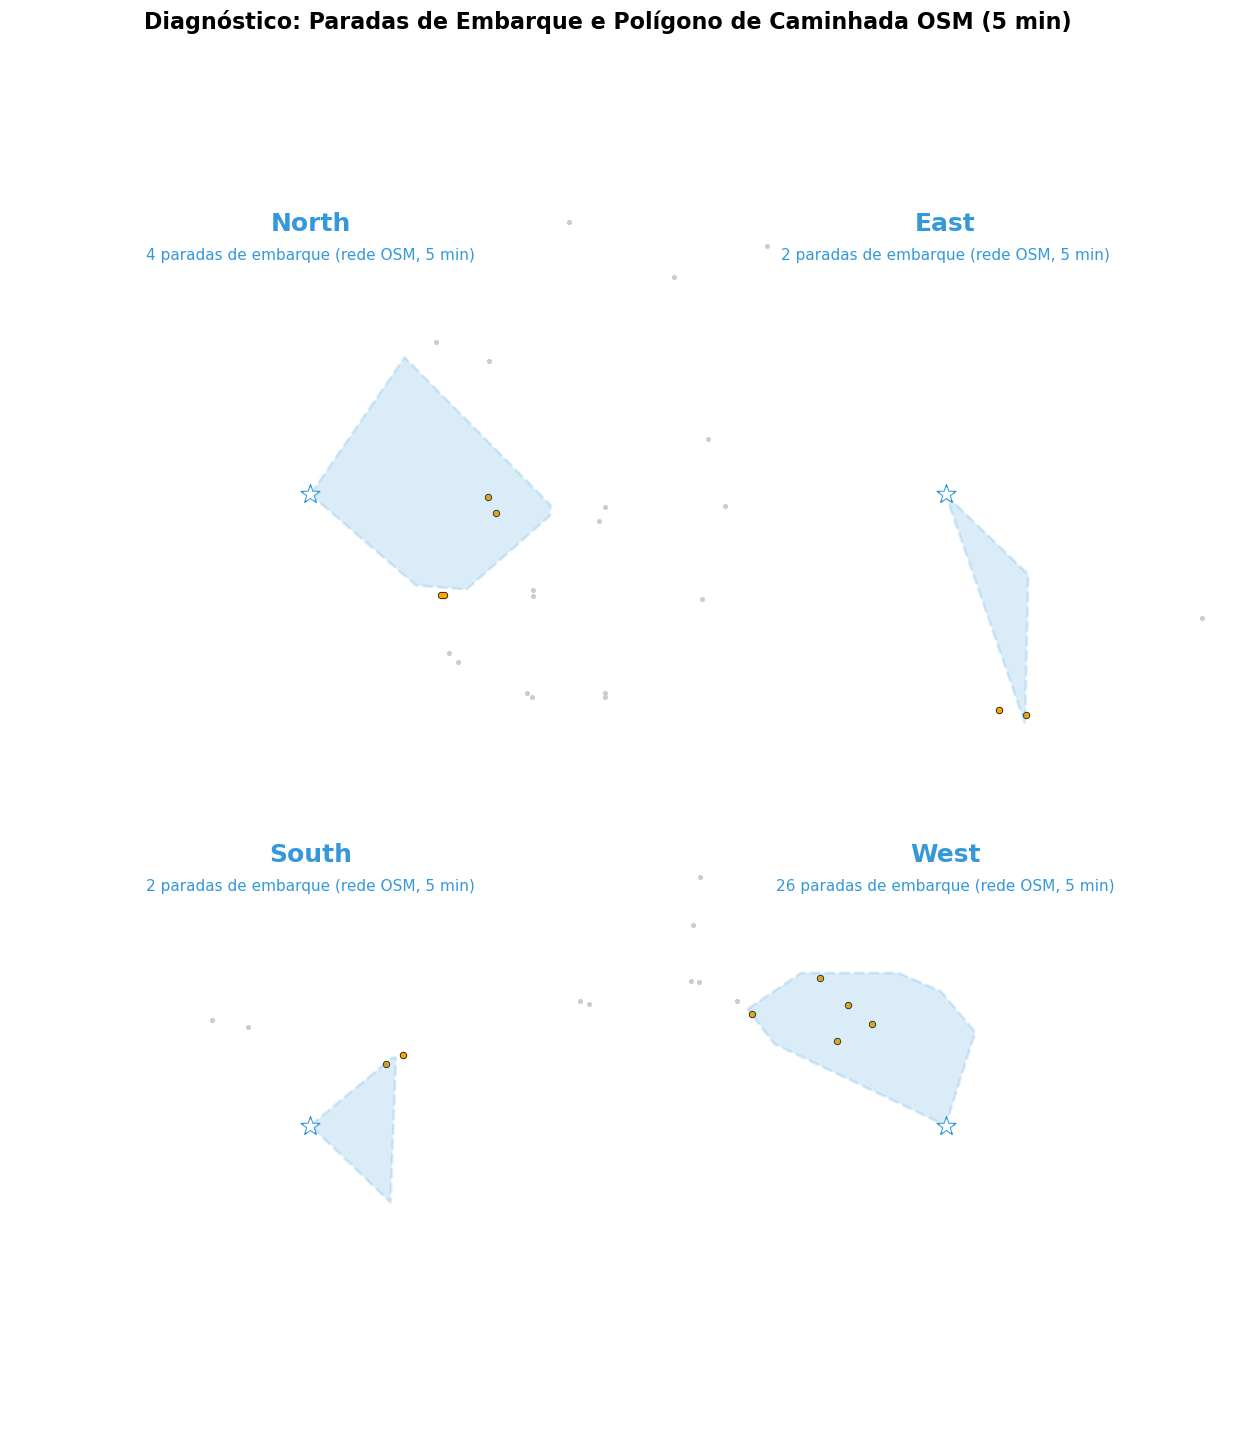

In [7]:
# ── Diagnóstico: paradas de embarque + polígono OSM walk (5 min) ──────────────

direction_order = ['North', 'East', 'South', 'West']

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
plt.subplots_adjust(hspace=0.05, wspace=0.05)

unique_s = gdf_stops_raw.drop_duplicates(subset='stop_id').copy()

# Extent fixo centrado na origem — consistente entre subplots
HALF = INITIAL_WALK_DIST_M * 1.8

for ax, direction in zip(axes.flat, direction_order):
    lat, lon = origins[direction]
    color = origin_colors[direction]
    result = isochrones[direction]

    origin_pt = (gpd.GeoDataFrame(geometry=[Point(lon, lat)], crs='EPSG:4326')
                 .to_crs('EPSG:29192')
                 .geometry.iloc[0])

    cx, cy = origin_pt.x, origin_pt.y
    xlim_d = (cx - HALF, cx + HALF)
    ylim_d = (cy - HALF, cy + HALF)

    # Paradas de contexto (no extent mas não de embarque)
    boarding_ids = set(result['boarding']['stop_id'])
    stops_ctx = unique_s[
        unique_s.geometry.x.between(*xlim_d) &
        unique_s.geometry.y.between(*ylim_d) &
        ~unique_s['stop_id'].isin(boarding_ids)
    ]
    if not stops_ctx.empty:
        stops_ctx.plot(ax=ax, color='#cccccc', markersize=7, marker='o', zorder=2)

    # Paradas de embarque
    gdf_board = result['boarding']
    if not gdf_board.empty:
        gdf_board.plot(ax=ax, color='black', markersize=18, marker='o', zorder=3)
        gdf_board.plot(ax=ax, color='orange',   markersize=10, marker='o', zorder=4)

    # Polígono de caminhada OSM
    walk_poly = result.get('walk_poly')
    if walk_poly is not None and not walk_poly.is_empty:
        gdf_walk_proj = (gpd.GeoDataFrame(geometry=[walk_poly], crs='EPSG:4326')
                         .to_crs('EPSG:29192'))
        gdf_walk_proj.plot(ax=ax, facecolor=color, alpha=0.18,
                           edgecolor=color, linewidth=2.0,
                           linestyle='--', zorder=5)

    # Origem
    origin_gdf = gpd.GeoDataFrame(geometry=[origin_pt], crs='EPSG:29192')
    origin_gdf.plot(ax=ax, color=color,   markersize=200, marker='*', zorder=6)
    origin_gdf.plot(ax=ax, color='white', markersize=90,  marker='*', zorder=7)

    ax.set_xlim(*xlim_d)
    ax.set_ylim(*ylim_d)
    ax.set_aspect('equal')
    ax.axis('off')

    n_b = len(gdf_board)
    ax.text(0.5, 0.97, direction,
            transform=ax.transAxes, ha='center', va='top',
            fontsize=18, fontweight='bold', color=color)
    ax.text(0.5, 0.91, f'{n_b} paradas de embarque (rede OSM, {INITIAL_WALK_MIN} min)',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=11, color=color)

fig.suptitle('Diagnóstico: Paradas de Embarque e Polígono de Caminhada OSM (5 min)',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

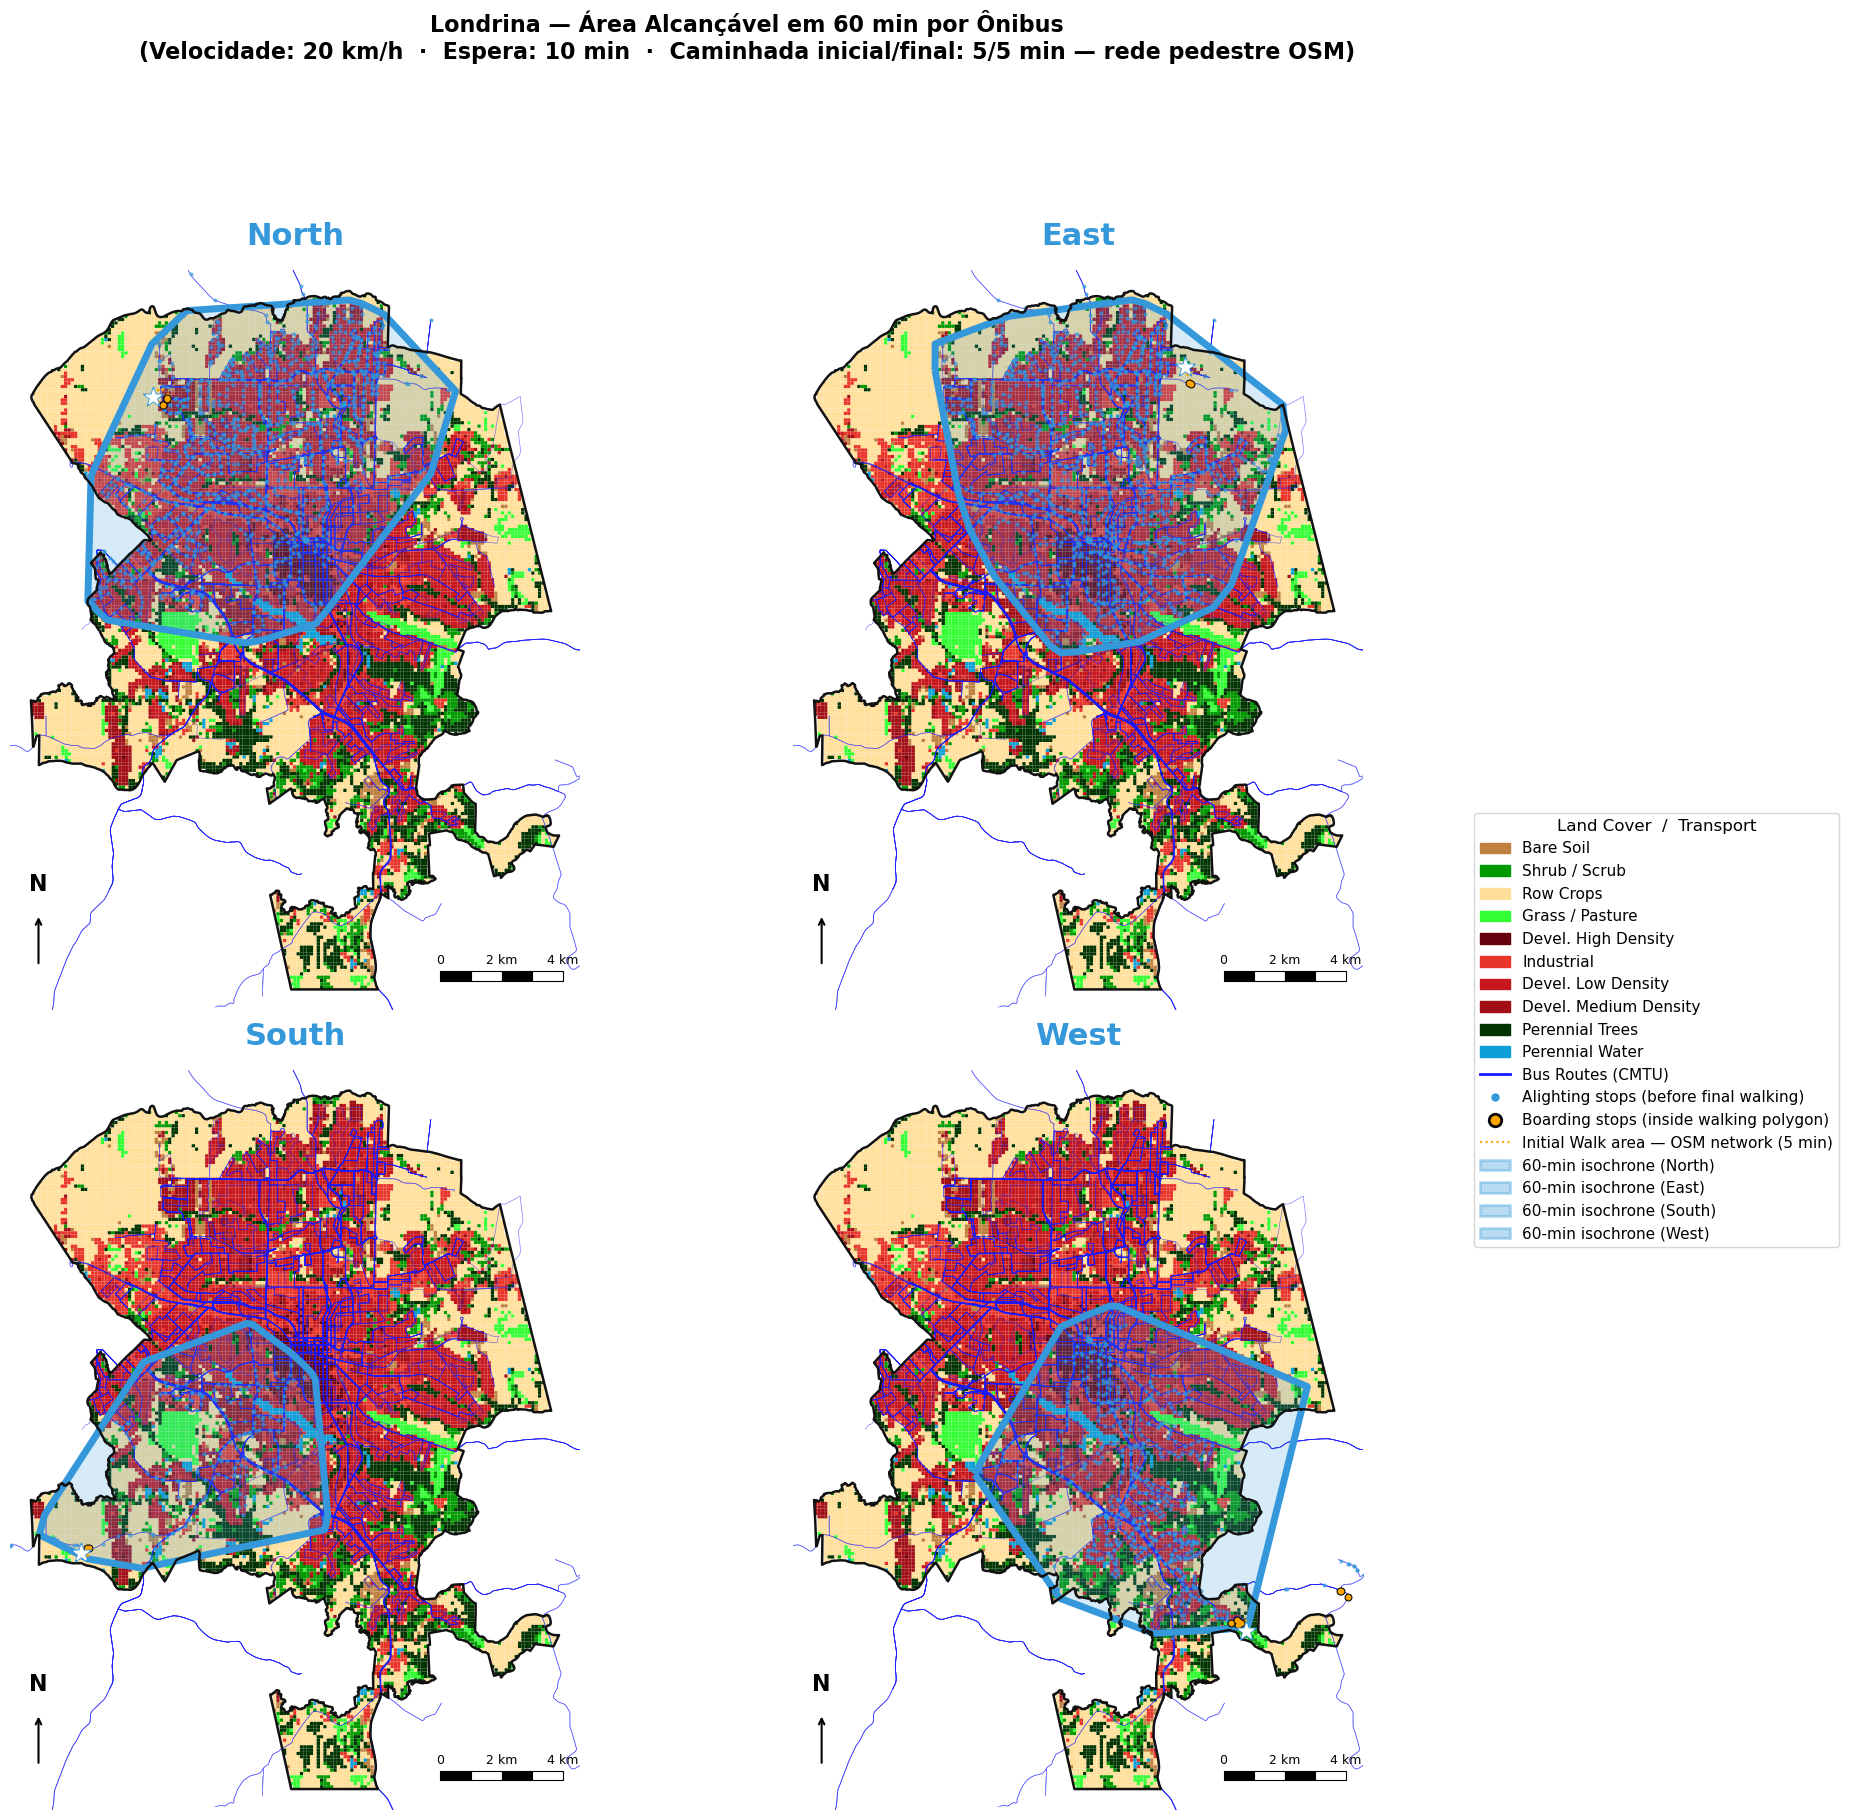

✅ Salvo: /Volumes/ssd_externo/landCoverlandValue/transportLondrina/mapas/isocronas_onibus_4pontos.pdf


In [8]:
# ── 4 plots estáticos (2×2) ───────────────────────────────────────────────────

def fmt_dist(m):
    return f'{int(m)} m' if m < 1000 else f'{m / 1000:.0f} km'

direction_order = ['North', 'East', 'South', 'West']

fig, axes = plt.subplots(2, 2, figsize=(22, 20))
plt.subplots_adjust(hspace=0.08, wspace=0.05, right=0.82)

# Extent fixo (perimetro + margem)
mnx, mny, mxx, mxy = gdf_per_proj.total_bounds
margin = 0.03 * max(mxx - mnx, mxy - mny)
xlim = (mnx - margin, mxx + margin)
ylim = (mny - margin, mxy + margin)

for ax, direction in zip(axes.flat, direction_order):
    lat, lon = origins[direction]
    color  = origin_colors[direction]
    result = isochrones[direction]

    # Origem em EPSG:29192 (usada na estrela)
    origin_pt_proj = (gpd.GeoDataFrame(geometry=[Point(lon, lat)], crs='EPSG:4326')
                      .to_crs('EPSG:29192')
                      .geometry.iloc[0])

    # 1. Land cover
    gdf_lc_proj.plot(ax=ax, color=gdf_lc_proj['color'],
                     linewidth=0, rasterized=True, zorder=1)

    # 2. Rotas de ônibus CMTU
    gdf_bus_proj.plot(ax=ax, color='#1a1aff',
                      linewidth=0.5, alpha=0.55, zorder=2)

    # 3. Polígono isócrona (envoltória convexa)
    poly = result['polygon']
    if poly is not None and not poly.is_empty:
        from shapely.ops import unary_union as su
        poly_hull = su([poly]).convex_hull
        gdf_iso = gpd.GeoDataFrame(geometry=[poly_hull], crs='EPSG:4326').to_crs('EPSG:29192')
        gdf_iso.plot(ax=ax, color=color, alpha=0.20, zorder=3)
        gdf_iso.boundary.plot(ax=ax, color=color, linewidth=5, zorder=4)

    # 3b. Área de caminhada inicial (polígono OSM walk, em vez de círculo)
    walk_poly = result.get('walk_poly')
    if walk_poly is not None and not walk_poly.is_empty:
        gdf_walk = (gpd.GeoDataFrame(geometry=[walk_poly], crs='EPSG:4326')
                    .to_crs('EPSG:29192'))
        gdf_walk.plot(ax=ax, facecolor='none', edgecolor='orange',
                      linewidth=2, linestyle=':', zorder=4)
    else:
        # fallback: círculo euclidiano
        gpd.GeoDataFrame(
            geometry=[origin_pt_proj.buffer(INITIAL_WALK_DIST_M)], crs='EPSG:29192'
        ).plot(ax=ax, facecolor='none', edgecolor=color,
               linewidth=1.5, linestyle='--', zorder=4)

    # 4. Paradas de desembarque (onde o ônibus pode levar)
    gdf_alight = result['alighting']
    if not gdf_alight.empty:
        gdf_alight.plot(ax=ax, color=color, markersize=4,
                        marker='o', alpha=0.6, zorder=5)

    # 5. Perimetro urbano
    gdf_per_proj.plot(ax=ax, facecolor='none',
                      edgecolor='#111111', linewidth=1.8, zorder=6)

    # 6. Paradas de embarque (acessíveis a pé da origem via OSM)
    gdf_board = result['boarding']
    if not gdf_board.empty:
        gdf_board.plot(ax=ax, color='black', markersize=22,
                       marker='o', zorder=7)
        gdf_board.plot(ax=ax, color='orange', markersize=10,
                       marker='o', zorder=7)

    # 7. Ponto de origem
    pt_gdf = gpd.GeoDataFrame(geometry=[origin_pt_proj], crs='EPSG:29192')
    pt_gdf.plot(ax=ax, color=color,   markersize=220, marker='*', zorder=8)
    pt_gdf.plot(ax=ax, color='white', markersize=120, marker='*', zorder=9)

    # Extent
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal')
    ax.axis('off')

    # Título
    ax.text(0.5, 1.025, direction, transform=ax.transAxes,
            ha='center', va='bottom', fontsize=22,
            fontweight='bold', color=color)

    # ── Scale bar ────────────────────────────────────────────────────────────
    ax_to_data = ax.transAxes + ax.transData.inverted()
    x_range = xlim[1] - xlim[0]
    y_range = ylim[1] - ylim[0]
    bar_len  = round(x_range / 5 / 1000) * 1000
    bar_h    = y_range * 0.013
    p_anchor = ax_to_data.transform((0.97, 0.04))
    x1, x0, y0 = p_anchor[0], p_anchor[0] - bar_len, p_anchor[1]
    for k in range(4):
        ax.add_patch(Rectangle(
            (x0 + k * bar_len / 4, y0), bar_len / 4, bar_h,
            facecolor='black' if k % 2 == 0 else 'white',
            edgecolor='black', linewidth=0.8, zorder=10
        ))
    tkw = dict(ha='center', va='bottom', fontsize=9, color='black', zorder=10)
    ax.text(x0,          y0 + bar_h * 1.4, '0',                **tkw)
    ax.text((x0+x1) / 2, y0 + bar_h * 1.4, fmt_dist(bar_len/2), **tkw)
    ax.text(x1,          y0 + bar_h * 1.4, fmt_dist(bar_len),   **tkw)

    # ── North arrow ──────────────────────────────────────────────────────────
    na = ax_to_data.transform((0.05, 0.06))
    arrow_len = y_range * 0.07
    ax.annotate('', xy=(na[0], na[1] + arrow_len), xytext=(na[0], na[1]),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5), zorder=10)
    ax.text(na[0], na[1] + arrow_len * 1.35, 'N',
            ha='center', va='bottom', fontsize=16,
            fontweight='bold', color='black', zorder=10)

# ── Suptitle ─────────────────────────────────────────────────────────────────
fig.suptitle(
    'Londrina — Área Alcançável em 60 min por Ônibus\n'
    f'(Velocidade: {BUS_SPEED_KMH:.0f} km/h  ·  '
    f'Espera: {WAITING_TIME_MIN} min  ·  '
    f'Caminhada inicial/final: {INITIAL_WALK_MIN}/{FINAL_WALK_MIN} min — rede pedestre OSM)',
    fontsize=16, fontweight='bold', y=1.01
)

# ── Legenda (lado direito) ────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=class_colors[c], label=class_labels[c])
    for c in class_colors
]
legend_handles += [
    plt.Line2D([0], [0], color='#1a1aff', linewidth=2,
               label='Bus Routes (CMTU)'),
    plt.Line2D([0], [0], color='#3498db', marker='o', markersize=5,
               linestyle='None', label='Alighting stops (before final walking)'),
    plt.Line2D([0], [0], color='orange', marker='o', markersize=9,
               markerfacecolor='orange', markeredgecolor='black', markeredgewidth=2,
               linestyle='None', label='Boarding stops (inside walking polygon)'),
    plt.Line2D([0], [0], color='orange', linewidth=1.5, linestyle=':',
               label=f'Initial Walk area — OSM network ({INITIAL_WALK_MIN} min)'),
]
for direction in direction_order:
    legend_handles.append(
        mpatches.Patch(facecolor=origin_colors[direction], alpha=0.35,
                       edgecolor=origin_colors[direction], linewidth=2,
                       label=f'60-min isochrone ({direction})')
    )

fig.legend(
    handles=legend_handles,
    loc='center right',
    bbox_to_anchor=(1.0, 0.5),
    fontsize=11,
    frameon=True,
    title='Land Cover  /  Transport',
    title_fontsize=12
)

# os.makedirs(os.path.dirname(OUTPUT_PDF), exist_ok=True)
# plt.savefig(OUTPUT_PDF, dpi=200, bbox_inches='tight')
plt.show()
print(f'✅ Salvo: {OUTPUT_PDF}')

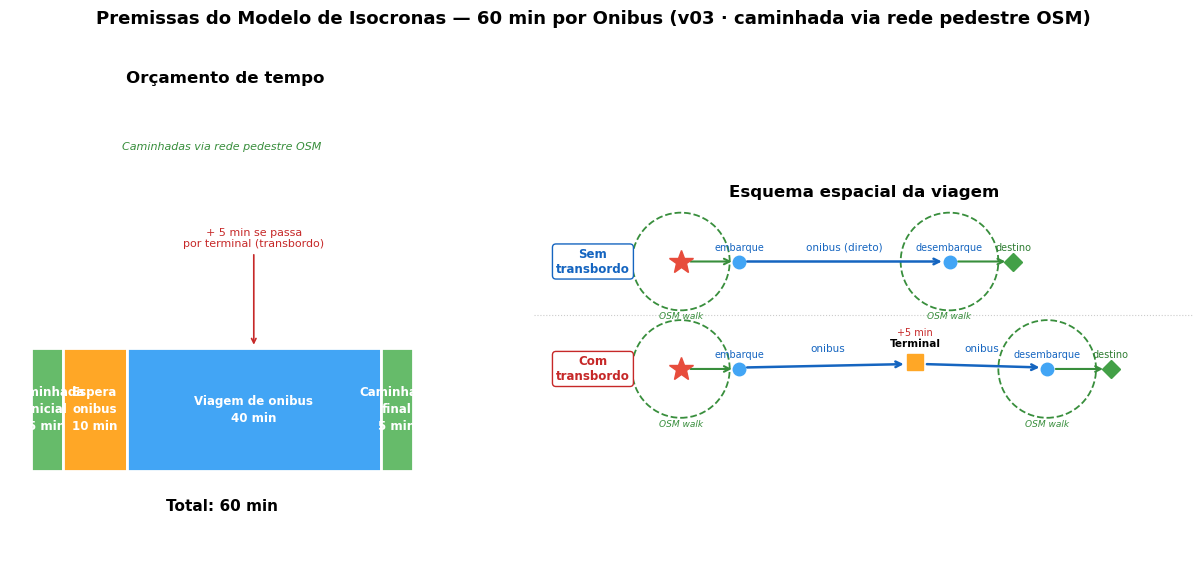

In [9]:
# ── Diagrama de premissas do modelo ──────────────────────────────────────────
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle

fig = plt.figure(figsize=(15, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.7], wspace=0.22)

# ════════════════════════════════════════════════════════════════════
# Painel esquerdo — orçamento de tempo
# ════════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0])
ax1.set_title('Orçamento de tempo', fontsize=12, fontweight='bold', pad=8)

segments = [
    (INITIAL_WALK_MIN, '#66bb6a', f'Caminhada\ninicial\n{INITIAL_WALK_MIN} min'),
    (WAITING_TIME_MIN, '#ffa726', f'Espera\nonibus\n{WAITING_TIME_MIN} min'),
    (EFFECTIVE_MIN,    '#42a5f5', f'Viagem de onibus\n{EFFECTIVE_MIN} min'),
    (FINAL_WALK_MIN,   '#66bb6a', f'Caminhada\nfinal\n{FINAL_WALK_MIN} min'),
]

x, bar_h = 0, 0.55
for dur, color, label in segments:
    ax1.barh(0, dur, left=x, height=bar_h,
             color=color, edgecolor='white', linewidth=2)
    ax1.text(x + dur / 2, 0, label,
             ha='center', va='center', fontsize=8.5,
             color='white', fontweight='bold', linespacing=1.4)
    x += dur

ax1.text(TOTAL_BUDGET_MIN / 2, -(bar_h / 2 + 0.12),
         f'Total: {TOTAL_BUDGET_MIN} min',
         ha='center', va='top', fontsize=11, fontweight='bold')

mid_bus = INITIAL_WALK_MIN + WAITING_TIME_MIN + EFFECTIVE_MIN / 2
ax1.annotate(
    f'+ {TRANSFER_PENALTY_MIN} min se passa\npor terminal (transbordo)',
    xy=(mid_bus, bar_h / 2),
    xytext=(mid_bus, 0.72),
    ha='center', fontsize=8, color='#c62828',
    arrowprops=dict(arrowstyle='->', color='#c62828', lw=1.2)
)

ax1.text(TOTAL_BUDGET_MIN / 2, 1.15,
         'Caminhadas via rede pedestre OSM',
         ha='center', fontsize=8, color='#388e3c', style='italic')

ax1.set_xlim(0, TOTAL_BUDGET_MIN + 1)
ax1.set_ylim(-0.65, 1.4)
ax1.axis('off')

# ════════════════════════════════════════════════════════════════════
# Painel direito — esquema espacial (2 cenários)
# ════════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[1])
ax2.set_title('Esquema espacial da viagem', fontsize=12, fontweight='bold', pad=8)
ax2.set_aspect('equal')
ax2.axis('off')

r = 1.0   # raio representativo dos polígonos de caminhada OSM

def draw_scenario(ax, y0, label, color_label, with_transfer=False):
    """Desenha um cenário de viagem na altura y0."""
    ox_pos, bx = 0.0, 1.2
    tx          = 4.8
    ax_pos      = 7.5 if with_transfer else 5.5

    # Rótulo do cenário
    ax.text(-1.8, y0, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color=color_label,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color_label, lw=1))

    # Polígonos de caminhada (irregular, representando rede OSM)
    for cx in [ox_pos, ax_pos]:
        ax.add_patch(Circle((cx, y0), r, fill=False,
                            linestyle='--', edgecolor='#388e3c', linewidth=1.3))
    ax.text(ox_pos, y0 - r - 0.18, 'OSM walk', ha='center',
            fontsize=6.5, color='#388e3c', style='italic')
    ax.text(ax_pos, y0 - r - 0.18, 'OSM walk', ha='center',
            fontsize=6.5, color='#388e3c', style='italic')

    # Origem
    ax.plot(ox_pos, y0, '*', color='#e74c3c', markersize=18, zorder=5)

    # Parada embarque
    ax.plot(bx, y0, 'o', color='#42a5f5', markersize=9, zorder=5)
    ax.text(bx, y0 + 0.22, 'embarque', ha='center', fontsize=7, color='#1565c0')

    # Seta caminhada inicial
    ax.annotate('', xy=(bx - 0.1, y0), xytext=(ox_pos + 0.14, y0),
                arrowprops=dict(arrowstyle='->', color='#388e3c', lw=1.5))

    if with_transfer:
        ax.plot(tx, y0 + 0.15, 's', color='#ffa726', markersize=12, zorder=5)
        ax.text(tx, y0 + 0.45, 'Terminal', ha='center', fontsize=7.5, fontweight='bold')
        ax.text(tx, y0 + 0.68,
                f'+{TRANSFER_PENALTY_MIN} min', ha='center', fontsize=7, color='#c62828')
        ax.annotate('', xy=(tx - 0.18, y0 + 0.1), xytext=(bx + 0.1, y0 + 0.03),
                    arrowprops=dict(arrowstyle='->', color='#1565c0', lw=1.8))
        ax.text((bx + tx) / 2, y0 + 0.35,
                'onibus', ha='center', fontsize=7.5, color='#1565c0')
        ax.annotate('', xy=(ax_pos - 0.1, y0 + 0.03), xytext=(tx + 0.18, y0 + 0.1),
                    arrowprops=dict(arrowstyle='->', color='#1565c0', lw=1.8))
        ax.text((tx + ax_pos) / 2, y0 + 0.35,
                'onibus', ha='center', fontsize=7.5, color='#1565c0')
    else:
        ax.annotate('', xy=(ax_pos - 0.1, y0), xytext=(bx + 0.1, y0),
                    arrowprops=dict(arrowstyle='->', color='#1565c0', lw=1.8))
        ax.text((bx + ax_pos) / 2, y0 + 0.22,
                'onibus (direto)', ha='center', fontsize=7.5, color='#1565c0')

    # Parada desembarque
    ax.plot(ax_pos, y0, 'o', color='#42a5f5', markersize=9, zorder=5)
    ax.text(ax_pos, y0 + 0.22, 'desembarque', ha='center', fontsize=7, color='#1565c0')

    # Seta caminhada final + destino
    dest_x = ax_pos + 1.2
    ax.annotate('', xy=(dest_x, y0), xytext=(ax_pos + 0.12, y0),
                arrowprops=dict(arrowstyle='->', color='#388e3c', lw=1.5))
    ax.plot(dest_x + 0.1, y0, 'D', color='#43a047', markersize=9, zorder=5)
    ax.text(dest_x + 0.1, y0 + 0.22, 'destino', ha='center', fontsize=7, color='#2e7d32')

# Cenário 1: sem transbordo
draw_scenario(ax2, y0= 1.2, label='Sem\ntransbordo', color_label='#1565c0',
              with_transfer=False)

ax2.axhline(y=0.1, xmin=0.0, xmax=1.0, color='#cccccc', linewidth=0.8, linestyle=':')

# Cenário 2: com transbordo
draw_scenario(ax2, y0=-1.0, label='Com\ntransbordo', color_label='#c62828',
              with_transfer=True)

ax2.set_xlim(-3.0, 10.5)
ax2.set_ylim(-2.5, 2.3)

fig.suptitle('Premissas do Modelo de Isocronas — 60 min por Onibus (v03 · caminhada via rede pedestre OSM)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Imports adicionais ────────────────────────────────────────────────────────
import folium
from branca.element import MacroElement
from jinja2 import Template as JinjaTemplate
import matplotlib.colors as mcolors
from pyproj import Transformer

# ── Caminhos ──────────────────────────────────────────────────────────────────
LANDVALUE_CSV = '/Volumes/ssd_externo/projects_full/Tabular/modelos_newTPS/etapa4/resultados/inferencia_Londrina_cfg60_450m2.csv'
OUTPUT_HTML   = '/Volumes/ssd_externo/landCoverlandValue/landcover_landvalue/Londrina_Isocronas_60min.html'

BUS_ISO_COLOR = '#e74c3c'

# ── Paleta tim.colors() ───────────────────────────────────────────────────────
def tim_colors(n=1000):
    colors = [
        '#000080','#0000CC','#0040FF','#0080FF','#00BFFF','#00FFFF',
        '#00FFBF','#00FF80','#00FF40','#00FF00','#40FF00','#80FF00',
        '#BFFF00','#FFFF00','#FFBF00','#FF8000','#FF4000','#FF0000'
    ]
    cmap = mcolors.LinearSegmentedColormap.from_list("tim", colors, N=n)
    return [mcolors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n)]

pal14 = tim_colors(1000)

# ── Centro do mapa ────────────────────────────────────────────────────────────
center_lat = np.mean([lat for lat, lon in origins.values()])
center_lon = np.mean([lon for lat, lon in origins.values()])

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='OpenStreetMap')

# ═══════════════════════════════════════════════════════════════════════════════
# LAYER 1: Land Values
# ═══════════════════════════════════════════════════════════════════════════════
print('[1/5] Valores do solo...')
fg_valores       = None
min_log_price    = None
max_log_price    = None

try:
    df_values     = pd.read_csv(LANDVALUE_CSV)
    if not (df_values['configuracao'] == 60).all():
        raise ValueError('O CSV contém previsões de outra configuração.')
    if not np.isclose(df_values['area_m2'], 450).all():
        raise ValueError('O CSV contém previsões para outra área de referência.')
    min_log_price = df_values['ln_unit_q50'].min()
    max_log_price = df_values['ln_unit_q50'].max()
    price_range   = max_log_price - min_log_price

    grid_spacing  = 109.45
    half_spacing  = grid_spacing / 2
    transf        = Transformer.from_crs("EPSG:29192", "EPSG:4326", always_xy=True)

    def _sq_utm(utm_x, utm_y, h):
        return Polygon([
            (utm_x-h, utm_y-h),(utm_x+h, utm_y-h),
            (utm_x+h, utm_y+h),(utm_x-h, utm_y+h),(utm_x-h, utm_y-h)
        ])

    def _poly_to_ll(poly):
        return [[lat, lon]
                for x, y in poly.exterior.coords
                for lon, lat in [transf.transform(x, y)]]

    def _price_color(p):
        idx = max(0, min(int((p - min_log_price) / price_range * (len(pal14)-1)), len(pal14)-1))
        return pal14[idx]

    feats_v = []
    for _, row in df_values.iterrows():
        sq    = _sq_utm(row['utm_x'], row['utm_y'], half_spacing)
        ll    = _poly_to_ll(sq)
        color = _price_color(row['ln_unit_q50'])
        feats_v.append({
            "type": "Feature",
            "geometry": {"type": "Polygon", "coordinates": [[[c[1],c[0]] for c in ll]]},
            "properties": {"fillColor": color, "color": color, "weight": 0, "fillOpacity": 0.7,
                           "popup": f"R$ {row['unit_q50']:,.0f}/m²"}
        })

    fg_valores = folium.FeatureGroup(name='Land Values', show=True, control=False)
    folium.GeoJson(
        {"type": "FeatureCollection", "features": feats_v},
        style_function=lambda f: {
            'fillColor': f['properties']['fillColor'], 'color': f['properties']['color'],
            'weight': 0, 'fillOpacity': f['properties']['fillOpacity'], 'opacity': 0
        },
        tooltip=folium.GeoJsonTooltip(fields=['popup'], aliases=['Value:'], labels=False)
    ).add_to(fg_valores)
    fg_valores.add_to(m)
    print(f'  ✓ {len(df_values):,} pontos')
except Exception as e:
    print(f'  ✗ {e}')

# ═══════════════════════════════════════════════════════════════════════════════
# LAYER 2: Land Cover
# ═══════════════════════════════════════════════════════════════════════════════
print('[2/5] Cobertura do solo...')
gdf_lc_plot = gdf_lc.copy()
gdf_lc_plot['label'] = gdf_lc_plot['predicted_class'].map(class_labels)

fg_cobertura = folium.FeatureGroup(name='Land Cover', show=True, control=False)
folium.GeoJson(
    gdf_lc_plot[['predicted_class', 'color', 'label', 'geometry']],
    style_function=lambda f: {
        'fillColor': f['properties']['color'], 'color': f['properties']['color'],
        'weight': 0, 'fillOpacity': 0.6
    },
    tooltip=folium.GeoJsonTooltip(fields=['label'], aliases=['Cover:'], labels=False)
).add_to(fg_cobertura)
fg_cobertura.add_to(m)
print(f'  ✓ {len(gdf_lc_plot):,} patches')

# ═══════════════════════════════════════════════════════════════════════════════
# LAYER 3: Road Infrastructure (G_walk — já carregado)
# ═══════════════════════════════════════════════════════════════════════════════
print('[3/5] Rede viária...')
highway_styles = {
    'motorway':     {'color': '#4B0082', 'weight': 3.5, 'opacity': 0.9},
    'trunk':        {'color': '#6A0DAD', 'weight': 3.0, 'opacity': 0.9},
    'primary':      {'color': '#8B008B', 'weight': 2.5, 'opacity': 0.9},
    'secondary':    {'color': '#9932CC', 'weight': 2.0, 'opacity': 0.9},
    'tertiary':     {'color': '#BA55D3', 'weight': 1.5, 'opacity': 0.9},
    'residential':  {'color': '#DDA0DD', 'weight': 0.5, 'opacity': 0.9},
    'unclassified': {'color': '#E6E6FA', 'weight': 0.4, 'opacity': 0.8},
    'living_street':{'color': '#F5DEB3', 'weight': 0.3, 'opacity': 0.7},
}

edges_all = ox.graph_to_gdfs(G_walk, nodes=False, edges=True)
road_layer_refs = {}
for hw_type, style in highway_styles.items():
    subset = edges_all[edges_all['highway'] == hw_type]
    if len(subset) > 0:
        fg_road = folium.FeatureGroup(show=True, control=False)
        folium.GeoJson(
            subset.__geo_interface__,
            style_function=lambda x, s=style: {
                'color': s['color'], 'weight': s['weight'], 'opacity': s['opacity']
            }
        ).add_to(fg_road)
        fg_road.add_to(m)
        road_layer_refs[hw_type] = fg_road
print(f'  ✓ {len(road_layer_refs)} tipos de via')

# ── Bus routes (CMTU) ────────────────────────────────────────────────────────
fg_bus_routes = folium.FeatureGroup(name='Bus Routes', show=True, control=False)
folium.GeoJson(
    gdf_bus.__geo_interface__,
    style_function=lambda x: {
        'color': '#e67e22', 'weight': 1.5, 'opacity': 0.7
    }
).add_to(fg_bus_routes)
fg_bus_routes.add_to(m)
print(f'  ✓ {len(gdf_bus)} rotas de ônibus (CMTU)')

# ── Origin markers ────────────────────────────────────────────────────────────
fg_markers = folium.FeatureGroup(name='Origins', show=True, control=False)
for direction, (olat, olon) in origins.items():
    folium.CircleMarker(
        location=[olat, olon], radius=10,
        popup=f"{direction} (Londrina)",
        color='black', fill=True,
        fillColor=origin_colors.get(direction, '#3498db'),
        fillOpacity=0.95, weight=2
    ).add_to(fg_markers)
fg_markers.add_to(m)

# ═══════════════════════════════════════════════════════════════════════════════
# LAYER 4: Isochrones per origin
# ═══════════════════════════════════════════════════════════════════════════════
print('[4/5] Isócronas...')
iso_layer_refs = {}
for direction, result in isochrones.items():
    fg = folium.FeatureGroup(show=False, control=False)

    walk_poly = result.get('walk_poly')
    if walk_poly is not None and not walk_poly.is_empty:
        try:
            folium.GeoJson(
                walk_poly.__geo_interface__,
                style_function=lambda x: {
                    'fillColor': '#f39c12', 'color': '#f39c12',
                    'weight': 1, 'fillOpacity': 0.3, 'opacity': 0.7
                }
            ).add_to(fg)
        except Exception as e:
            print(f'  ✗ walk_poly {direction}: {e}')

    poly = result.get('polygon')
    if poly is not None and not poly.is_empty:
        try:
            folium.GeoJson(
                poly.__geo_interface__,
                style_function=lambda x: {
                    'fillColor': BUS_ISO_COLOR, 'color': BUS_ISO_COLOR,
                    'weight': 2, 'fillOpacity': 0.25, 'opacity': 0.8
                }
            ).add_to(fg)
        except Exception as e:
            print(f'  ✗ poly {direction}: {e}')

    fg.add_to(m)
    iso_layer_refs[direction] = fg
    print(f'  ✓ {direction}')

# Urban perimeter
folium.GeoJson(
    gdf_per.__geo_interface__,
    style_function=lambda x: {
        'fillColor': 'none', 'color': '#333333',
        'weight': 2, 'fillOpacity': 0, 'opacity': 0.7
    }
).add_to(m)

# ═══════════════════════════════════════════════════════════════════════════════
# UI PANELS + JAVASCRIPT
# ═══════════════════════════════════════════════════════════════════════════════
print('[5/5] Painéis e JavaScript...')

js_map_var       = m.get_name()
js_valores_var   = fg_valores.get_name() if fg_valores else 'null'
js_cobertura_var = fg_cobertura.get_name()
js_roads_str     = '{' + ', '.join(f'"{hw}": {fg.get_name()}' for hw, fg in road_layer_refs.items()) + '}'
js_iso_str       = '{' + ', '.join(f'"{d}": {fg.get_name()}' for d, fg in iso_layer_refs.items()) + '}'
js_bus_var        = fg_bus_routes.get_name()

# ── Panel 1: Land Values ──────────────────────────────────────────────────────
panel_valores_html = """
<div id="panel-valores" style="position:fixed;top:10px;left:10px;width:280px;height:auto;
     background-color:white;border:2px solid #333;border-radius:8px;z-index:9999;
     font-size:9px;padding:12px;font-family:monospace;box-shadow:0 0 10px rgba(0,0,0,0.3);">
<div style="display:flex;justify-content:space-between;align-items:center;
     border-bottom:2px solid #333;padding-bottom:8px;margin-bottom:10px;">
    <h4 style="margin:0;font-size:11px;color:#333;">Median Urban Land Values-2024 (R$/m²)</h4>
    <label style="font-size:9px;cursor:pointer;white-space:nowrap;margin-left:8px;">
        <input type="checkbox" id="toggle-valores" checked> Show
    </label>
</div>
<table style="width:100%;font-size:8px;border-collapse:collapse;">
"""
if min_log_price is not None:
    breaks_real = np.exp(np.linspace(min_log_price, max_log_price, 10))
    for i in range(len(breaks_real) - 1):
        color = pal14[int((i / (len(breaks_real)-2)) * (len(pal14)-1))]
        panel_valores_html += f"""
        <tr style="border-bottom:1px solid #ddd;">
            <td style="width:20px;height:10px;background-color:{color};border:1px solid #999;"></td>
            <td style="padding-left:8px;font-size:8px;">R$ {breaks_real[i]:,.0f} – {breaks_real[i+1]:,.0f}</td>
        </tr>"""
panel_valores_html += "</table></div>"
m.get_root().html.add_child(folium.Element(panel_valores_html))

# ── Panel 2: Land Cover ───────────────────────────────────────────────────────
panel_cobertura_html = """
<div id="panel-cobertura" style="position:fixed;top:0;left:10px;width:280px;height:auto;
     background-color:white;border:2px solid #333;border-radius:8px;z-index:9999;
     font-size:9px;padding:12px;font-family:monospace;box-shadow:0 0 10px rgba(0,0,0,0.3);">
<div style="display:flex;justify-content:space-between;align-items:center;
     border-bottom:2px solid #333;padding-bottom:8px;margin-bottom:10px;">
    <h4 style="margin:0;font-size:11px;color:#333;">Urban Land Cover Classes-2024</h4>
    <label style="font-size:9px;cursor:pointer;white-space:nowrap;margin-left:8px;">
        <input type="checkbox" id="toggle-cobertura" checked> Show
    </label>
</div>
<table style="width:100%;font-size:8px;border-collapse:collapse;">
"""
for ck in ['hduf','mduf','lduf','industrial','bare','grass','bush','tree','water','crop']:
    panel_cobertura_html += f"""
    <tr style="border-bottom:1px solid #ddd;">
        <td style="width:20px;height:12px;background-color:{class_colors[ck]};border:1px solid #999;"></td>
        <td style="padding-left:8px;"><b>{class_labels[ck]}</b></td>
    </tr>"""
panel_cobertura_html += "</table></div>"
m.get_root().html.add_child(folium.Element(panel_cobertura_html))

# ── Panel 3: Transport Network ────────────────────────────────────────────────
panel_network_html = """
<div id="panel-network" style="position:fixed;top:0;left:10px;width:280px;height:auto;
     background-color:white;border:2px solid #333;border-radius:8px;z-index:9999;
     font-size:9px;padding:12px;font-family:monospace;box-shadow:0 0 10px rgba(0,0,0,0.3);">
<h4 style="margin:0 0 10px 0;text-align:center;font-size:11px;color:#333;
    border-bottom:2px solid #333;padding-bottom:8px;">Transport Network Infrastructure</h4>
<table style="width:100%;font-size:8px;border-collapse:collapse;">
"""
for hw_type, style in highway_styles.items():
    panel_network_html += f"""
    <tr style="border-bottom:1px solid #ddd;">
        <td style="width:30px;height:3px;background-color:{style['color']};border:1px solid {style['color']};"></td>
        <td style="padding-left:8px;">
            <label style="cursor:pointer;">
                <input type="checkbox" class="toggle-road" data-road="{hw_type}" checked>
                <b>{hw_type.capitalize()}</b>
            </label>
        </td>
    </tr>"""
panel_network_html += """
<tr style="border-top:2px solid #bbb;">
    <td style="width:30px;height:3px;background-color:#e67e22;border:1px solid #e67e22;"></td>
    <td style="padding-left:8px;">
        <label style="cursor:pointer;">
            <input type="checkbox" id="toggle-bus-routes" checked>
            <b>Bus Network (CMTU)</b>
        </label>
    </td>
</tr>"""
panel_network_html += "</table></div>"
m.get_root().html.add_child(folium.Element(panel_network_html))

# ── Panel 4: Commuting Selector ───────────────────────────────────────────────
panel_commuting_html = f"""
<div id="panel-commuting" style="position:fixed;top:10px;right:10px;width:320px;height:auto;
     background-color:white;border:2px solid #333;border-radius:8px;z-index:9999;
     font-size:10px;padding:15px;font-family:monospace;box-shadow:0 0 15px rgba(0,0,0,0.3);">
<h4 style="margin:0 0 12px 0;text-align:center;font-size:12px;color:#333;
    border-bottom:2px solid #333;padding-bottom:8px;">Commuting Analysis — Londrina</h4>
<p style="margin:8px 0;font-size:9px;color:#666;">
    <b>Travel Time Budget:</b> {int(TOTAL_BUDGET_MIN)} min<br/>
    <b>Mode:</b> Bus (CMTU) + Walking<br/>
    <b>Parameters:</b> {int(BUS_SPEED_KMH)} km/h · {int(INITIAL_WALK_MIN)}+{int(FINAL_WALK_MIN)} min walk · {int(WAITING_TIME_MIN)} min waiting
</p>
<hr style="margin:8px 0;border:none;border-top:1px solid #ddd;">
<div style="margin-bottom:10px;">
    <label style="font-size:10px;font-weight:bold;color:#333;display:block;margin-bottom:5px;">
        Commuting Origin:
    </label>
    <select id="origin-select" style="width:100%;padding:5px;font-size:10px;font-family:monospace;
                   border:1px solid #999;border-radius:4px;">
"""
for direction, (olat, olon) in origins.items():
    selected = ' selected' if direction == list(origins.keys())[0] else ''
    panel_commuting_html += f'<option value="{direction}"{selected}>{direction} ({olat:.4f}, {olon:.4f})</option>\n'
panel_commuting_html += f"""
    </select>
</div>
<hr style="margin:8px 0;border:none;border-top:1px solid #ddd;">
<p style="margin:5px 0;font-size:9px;font-weight:bold;color:#333;">Origins:</p>
<table style="width:100%;font-size:8px;border-collapse:collapse;">
"""
for direction, (olat, olon) in origins.items():
    oc = origin_colors.get(direction, '#3498db')
    panel_commuting_html += f"""
    <tr>
        <td style="width:14px;height:14px;background-color:{oc};border:2px solid black;border-radius:50%;"></td>
        <td style="padding-left:8px;"><b>{direction}</b></td>
    </tr>"""
panel_commuting_html += f"""
</table>
<p style="margin:8px 0 5px 0;font-size:9px;font-weight:bold;color:#333;">Isochrone Colors:</p>
<table style="width:100%;font-size:8px;border-collapse:collapse;">
    <tr>
        <td style="width:20px;height:12px;background-color:{BUS_ISO_COLOR};opacity:0.7;border:1px solid {BUS_ISO_COLOR};"></td>
        <td style="padding-left:8px;"><b>Bus reachable area (60 min)</b></td>
    </tr>
    <tr>
        <td style="width:20px;height:12px;background-color:#f39c12;opacity:0.7;border:1px solid #f39c12;"></td>
        <td style="padding-left:8px;">Initial walk area (5 min)</td>
    </tr>
</table>
</div>
"""
m.get_root().html.add_child(folium.Element(panel_commuting_html))

# ── Panel 5: Methodological Notes ─────────────────────────────────────────────
panel_notes_html = f"""
<div id="panel-notes" style="position:fixed;top:0;right:10px;width:320px;height:auto;
     background-color:white;border:2px solid #333;border-radius:8px;z-index:9999;
     font-size:10px;padding:15px;font-family:monospace;
     box-shadow:0 0 15px rgba(0,0,0,0.3);max-height:55vh;overflow-y:auto;">
<h4 style="margin:0 0 10px 0;text-align:center;font-size:11px;color:#333;
    border-bottom:2px solid #333;padding-bottom:8px;">Methodological Notes</h4>
<div style="font-size:8px;color:#666;line-height:1.4;">
    <b>Transport mode: Bus (CMTU real network)</b><br/><br/>
    <b>Bus speed:</b> {BUS_SPEED_KMH:.0f} km/h<br/>
    <b>Initial walk:</b> {INITIAL_WALK_MIN} min (~{INITIAL_WALK_DIST_M:.0f} m at 5 km/h)<br/>
    <b>Waiting time:</b> {WAITING_TIME_MIN} min at origin stop<br/>
    <b>Final walk:</b> {FINAL_WALK_MIN} min (~{FINAL_WALK_DIST_M:.0f} m at 5 km/h)<br/>
    <b>Transfer penalty:</b> {TRANSFER_PENALTY_MIN} min per terminal<br/>
    <b>Effective bus time:</b> {EFFECTIVE_MIN} min<br/><br/>
    <b>Isochrone model (v03):</b><br/>
    • Initial walk: Dijkstra on OSM walk network<br/>
    • Bus travel: Dijkstra on CMTU DiGraph<br/>
    • Final walk: Multi-source Dijkstra on OSM<br/>
    • Isochrones clipped to urban perimeter<br/><br/>
    <b>Data sources:</b><br/>
    • OSM: base map + pedestrian network<br/>
    • CMTU: bus routes + stops (real network)<br/>
    • TabPFN: Land Values (median prediction)<br/>
    • DINOv2+LoRA: Land Cover Classification
</div>
</div>
"""
m.get_root().html.add_child(folium.Element(panel_notes_html))

# ── JavaScript ────────────────────────────────────────────────────────────────
js_template = """
    var _map = __MAP__;
    var _valoresLayer  = __VALORES__;
    var _coberturaLayer= __COBERTURA__;
    var _roadLayers    = __ROADS__;
    var _isoLayers     = __ISO__;
    var _busRoutesLayer= __BUS_ROUTES__;

    if (_valoresLayer  && !_map.hasLayer(_valoresLayer))  { _map.addLayer(_valoresLayer);  }
    if (_coberturaLayer && !_map.hasLayer(_coberturaLayer)){ _map.addLayer(_coberturaLayer);}
    for (var _rk in _roadLayers) {
        if (!_map.hasLayer(_roadLayers[_rk])) { _map.addLayer(_roadLayers[_rk]); }
    }
    for (var _k in _isoLayers) { try { _map.removeLayer(_isoLayers[_k]); } catch(e) {} }
    if (_busRoutesLayer && !_map.hasLayer(_busRoutesLayer)) { _map.addLayer(_busRoutesLayer); }

    function _setupCtrl() {
        var cbV = document.getElementById('toggle-valores');
        if (!cbV) { setTimeout(_setupCtrl, 150); return; }

        if (_valoresLayer) {
            cbV.addEventListener('change', function() {
                if (this.checked) _map.addLayer(_valoresLayer);
                else _map.removeLayer(_valoresLayer);
            });
        } else { cbV.disabled = true; cbV.parentElement.style.opacity = '0.4'; }

        var panelValores   = document.getElementById('panel-valores');
        var panelCobertura = document.getElementById('panel-cobertura');
        function placeCobertura() {
            if (panelValores && panelCobertura)
                panelCobertura.style.top = (panelValores.offsetTop + panelValores.offsetHeight + 10) + 'px';
        }
        window.addEventListener('resize', placeCobertura); placeCobertura();

        var cbC = document.getElementById('toggle-cobertura');
        if (_coberturaLayer) {
            cbC.addEventListener('change', function() {
                if (this.checked) _map.addLayer(_coberturaLayer);
                else _map.removeLayer(_coberturaLayer);
            });
        } else { cbC.disabled = true; cbC.parentElement.style.opacity = '0.4'; }

        var panelNetwork = document.getElementById('panel-network');
        function placeNetwork() {
            if (panelCobertura && panelNetwork)
                panelNetwork.style.top = (panelCobertura.offsetTop + panelCobertura.offsetHeight + 10) + 'px';
        }
        window.addEventListener('resize', placeNetwork); placeNetwork();

        document.querySelectorAll('.toggle-road').forEach(function(cb) {
            cb.addEventListener('change', function() {
                var rt = this.getAttribute('data-road');
                if (_roadLayers[rt]) {
                    if (this.checked) _map.addLayer(_roadLayers[rt]);
                    else _map.removeLayer(_roadLayers[rt]);
                }
            });
        });

        var cbBus = document.getElementById('toggle-bus-routes');
        if (_busRoutesLayer) {
            cbBus.addEventListener('change', function() {
                if (this.checked) _map.addLayer(_busRoutesLayer);
                else _map.removeLayer(_busRoutesLayer);
            });
        } else { cbBus.disabled = true; cbBus.parentElement.style.opacity = '0.4'; }

        var notes   = document.getElementById('panel-notes');
        var commute = document.getElementById('panel-commuting');
        function placeNotes() {
            if (notes && commute)
                notes.style.top = (commute.offsetTop + commute.offsetHeight + 10) + 'px';
        }
        window.addEventListener('resize', placeNotes); placeNotes();

        var oSel = document.getElementById('origin-select');
        function updateIso() {
            for (var k in _isoLayers) { try { _map.removeLayer(_isoLayers[k]); } catch(e) {} }
            if (_isoLayers[oSel.value]) { _map.addLayer(_isoLayers[oSel.value]); }
        }
        oSel.addEventListener('change', updateIso);
        updateIso();
    }
    _setupCtrl();
"""

js_body = (js_template
    .replace('__MAP__',       js_map_var)
    .replace('__VALORES__',   js_valores_var)
    .replace('__COBERTURA__', js_cobertura_var)
    .replace('__ROADS__',     js_roads_str)
    .replace('__ISO__',       js_iso_str)
    .replace('__BUS_ROUTES__', js_bus_var)
)

controller = MacroElement()
controller._template = JinjaTemplate(
    '{%' + ' macro script(this, kwargs) ' + '%}'
    + '{%' + ' raw ' + '%}'
    + js_body
    + '{%' + ' endraw ' + '%}'
    + '{%' + ' endmacro ' + '%}'
)
m.add_child(controller)

# ── Salvar HTML ───────────────────────────────────────────────────────────────
m.save(OUTPUT_HTML)
print(f'\n✅ HTML salvo em: {OUTPUT_HTML}')


[1/5] Valores do solo...
  ✓ 18,384 pontos
[2/5] Cobertura do solo...
  ✓ 18,302 patches
[3/5] Rede viária...
  ✓ 7 tipos de via
  ✓ 645 rotas de ônibus (CMTU)
[4/5] Isócronas...
  ✓ North
  ✓ East
  ✓ South
  ✓ West
[5/5] Painéis e JavaScript...

✅ HTML salvo em: /Volumes/ssd_externo/landCoverlandValue/landcover_landvalue/Londrina_Isocronas_60minNEW.html
